# FinBERT Sentiment Analysis — NVIDIA 10-K / 10-Q MD&A Sentences

**Data source**: `Data Preparation/mda_processed_sample.xlsx`  
64 NVIDIA filings (10-K annual + 10-Q quarterly), 2010 – 2025, ~12 000 sentences after reshaping.

**Pipeline**
1. Load & reshape wide→long (one row = one sentence)
2. Reconstruct readable text from pre-tokenised columns
3. **Artificial labelling** via Loughran-McDonald (LM) financial lexicon  
   *(positive word count > negative → positive; inverse → negative; else neutral)*
4. Time-based **stratified train/test split** (≤ 2022 train, 2023+ test)
5. Stratified sample for CPU-friendly FinBERT fine-tuning  
   *(remove the sampling cell to train on the full dataset with a GPU)*
6. **Fine-tune FinBERT** (`ProsusAI/finbert`)
7. Evaluate: Precision · Recall · F1 (Macro & Weighted) · Confusion Matrix
8. **Loughran-McDonald + SVM** baseline comparison

## 1. Imports & Setup

In [1]:
import warnings, re
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset as HFDataset

plt.rcParams['figure.dpi'] = 110
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
print(f'Device   : {DEVICE}')


PyTorch  : 2.10.0
CUDA     : False
Device   : cpu


## 2. Load & Reshape the MD&A Dataset

The Excel file is **wide-format**: each row is one filing; columns `sent_1 … sent_N`
hold individual sentences (pre-tokenised, lowercased, comma-separated tokens).
We melt it to **long-format** (one row = one sentence) and reconstruct readable text.

In [2]:
RAW_PATH = '../Data Preparation/mda_processed_sample.xlsx'

raw = pd.read_excel(RAW_PATH)
print(f'Raw shape: {raw.shape}')
print(f'Filings  : {raw["doc"].nunique()}')

sent_cols = [c for c in raw.columns if c.startswith('sent_')]
print(f'Sent cols: {len(sent_cols)}')


Raw shape: (64, 452)
Filings  : 64
Sent cols: 451


In [3]:
# ── melt wide → long ─────────────────────────────────────────────────────────
long = (raw.melt(id_vars='doc', value_vars=sent_cols,
                 var_name='sent_col', value_name='tokens')
           .dropna(subset=['tokens'])
           .reset_index(drop=True))

# Reconstruct sentence text: split comma-separated tokens → join with spaces
long['processed_text'] = long['tokens'].apply(
    lambda t: ' '.join(str(t).split(', ')))

# Filter out very short fragments (< 6 words)
long = long[long['processed_text'].str.split().str.len() >= 6].reset_index(drop=True)

# ── parse metadata from doc name ──────────────────────────────────────────────
# Format: NVIDIA_10-K_2010-03-18_MDA.txt
def parse_doc(doc_name):
    parts = doc_name.replace('_MDA.txt', '').split('_')
    ticker       = parts[0]
    filing_type  = parts[1]          # 10-K or 10-Q
    date_str     = parts[2]
    dt           = pd.to_datetime(date_str)
    month        = dt.month
    quarter      = f'Q{(month - 1) // 3 + 1}'
    return ticker, filing_type, dt, str(dt.year), quarter

meta = long['doc'].apply(lambda d: pd.Series(
    parse_doc(d), index=['ticker', 'filing_type', 'date', 'year', 'quarter']))
long = pd.concat([long[['doc', 'processed_text']], meta], axis=1)

print(f'Total sentences : {len(long):,}')
print(f'Date range      : {long["date"].min().date()} → {long["date"].max().date()}')
print(f'Filing types    : {long["filing_type"].value_counts().to_dict()}')
print()
long.head(6)


Total sentences : 11,855
Date range      : 2010-03-18 → 2025-11-19
Filing types    : {'10-Q': 7532, '10-K': 4323}



,doc,processed_text,ticker,filing_type,date,year,quarter
0,NVIDIA_10-K_2010-03-18_MDA.txt,overview our company nvidia corporation helped...,NVIDIA,10-K,2010-03-18,2010,Q1
1,NVIDIA_10-K_2011-03-16_MDA.txt,overview our company nvidia corporation invent...,NVIDIA,10-K,2011-03-16,2011,Q1
2,NVIDIA_10-K_2012-03-13_MDA.txt,overview our company nvidia is known to millio...,NVIDIA,10-K,2012-03-13,2012,Q1
3,NVIDIA_10-K_2013-03-12_MDA.txt,overview our company nvidia is a visual comput...,NVIDIA,10-K,2013-03-12,2013,Q1
4,NVIDIA_10-K_2014-03-13_MDA.txt,overview our company nvidia is a visual comput...,NVIDIA,10-K,2014-03-13,2014,Q1
5,NVIDIA_10-K_2015-03-12_MDA.txt,overview our company and our businesses nvidia...,NVIDIA,10-K,2015-03-12,2015,Q1


## 3. Artificial Labelling — Loughran-McDonald Financial Lexicon

Because the sentences carry no human sentiment labels, we assign **pseudo-labels**
using the Loughran-McDonald (LM) financial sentiment dictionary — the standard
word list designed specifically for financial text.

**Rule**:
- `positive_count > negative_count` → **positive**
- `negative_count > positive_count` → **negative**
- `positive_count == negative_count` (including both zero) → **neutral**

These labels serve as proxy ground truth for the supervised fine-tuning step.

In [4]:
# Loughran-McDonald word lists (core subsets)
LM_POSITIVE = {
    'achieve','achievement','advantage','benefit','best','better','boost',
    'confident','deliver','effective','efficiency','enhance','exceed','excellent',
    'exceptional','expand','favorable','gain','good','grew','growth','high',
    'higher','improve','improved','improvement','increase','increased','innovative',
    'leading','maximize','opportunity','outperform','positive','profit',
    'profitability','profitable','progress','record','return','revenue','rising',
    'strong','stronger','success','successful','superior','surpass','robust',
    'accelerate','accelerated','advance','advanced','breakthrough','momentum',
    'outstanding','remarkable','significant','substantial','exceed','exceeded',
    'benefited','benefiting','upside','recovered','recovery','strengthen','strengthened',
    'optimistic','optimism','growing','thriving','valuable','innovation',
}

LM_NEGATIVE = {
    'adverse','against','below','burden','challenge','challenging','charge',
    'charges','costly','decline','declined','declining','decrease','decreased',
    'deficit','deteriorate','difficulties','difficult','disruption','downturn',
    'drop','failed','failure','fall','headwinds','impairment','impair','inadequate',
    'inflation','inflationary','investigation','issue','litigation','loss','losses',
    'lower','negative','penalty','poor','pressure','problem','reduce','reduced',
    'restructuring','risk','risks','shortage','slow','slowdown','uncertain',
    'uncertainty','unfavorable','weak','weakness','concern','concerns','constrained',
    'constraint','competitive','competition','delay','delayed','disappoint',
    'disappointed','disappointing','downturn','erode','eroded','exposure',
    'impacted','negatively','obstacle','slowdown','softness','unfavorable',
    'volatile','volatility','writedown','write-down','default','delinquent',
    'downgrade','downgraded','underperform','underperformed','falling',
}

def lm_label(text):
    words = set(text.lower().split())
    pos   = len(words & LM_POSITIVE)
    neg   = len(words & LM_NEGATIVE)
    if pos > neg:   return 'positive'
    if neg > pos:   return 'negative'
    return 'neutral'

long['sentiment_label'] = long['processed_text'].apply(lm_label)

print('Label distribution (all sentences):')
vc = long['sentiment_label'].value_counts()
print(vc)
print()
print('Label proportions:')
print(vc / len(long))


Label distribution (all sentences):
sentiment_label
neutral     5821
positive    4110
negative    1924
Name: count, dtype: int64

Label proportions:
sentiment_label
neutral     0.491016
positive    0.346689
negative    0.162294
Name: count, dtype: float64


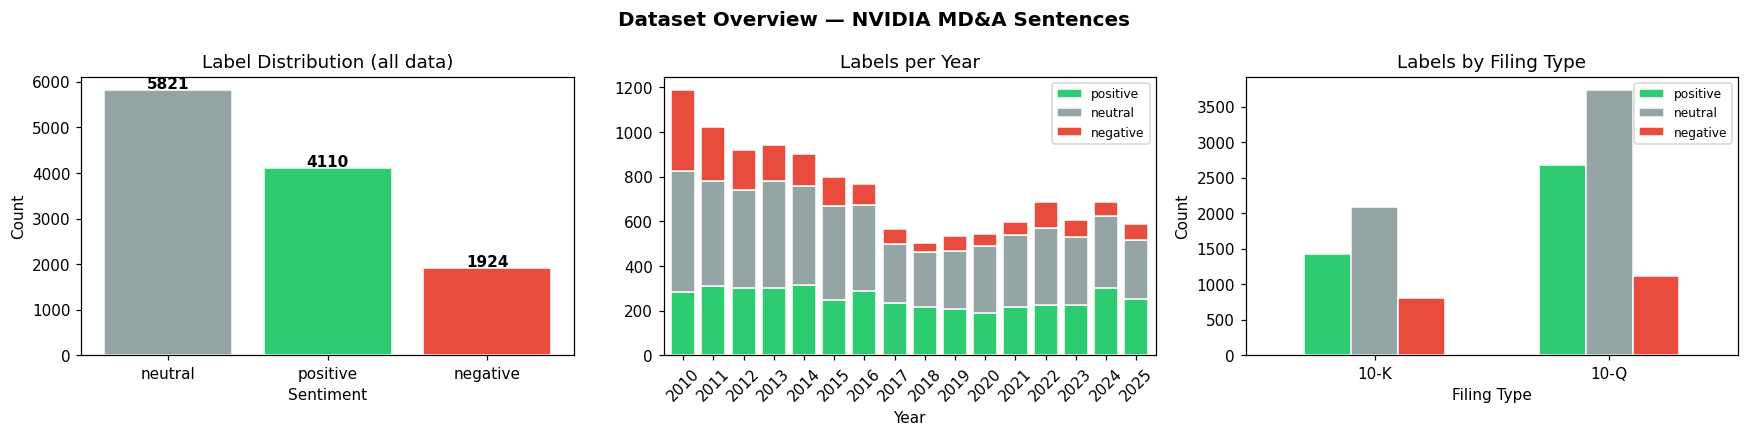

In [5]:
# ── Visualise label distribution and temporal spread ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Dataset Overview — NVIDIA MD&A Sentences', fontsize=13, fontweight='bold')

palette = {'positive': '#2ecc71', 'neutral': '#95a5a6', 'negative': '#e74c3c'}

# Label counts
vc_plot = long['sentiment_label'].value_counts()
axes[0].bar(vc_plot.index, vc_plot.values,
            color=[palette[l] for l in vc_plot.index], edgecolor='white')
axes[0].set_title('Label Distribution (all data)')
axes[0].set_xlabel('Sentiment'); axes[0].set_ylabel('Count')
for i, (lbl, cnt) in enumerate(vc_plot.items()):
    axes[0].text(i, cnt + 30, str(cnt), ha='center', fontweight='bold')

# Labels per year
long['year_int'] = long['date'].dt.year
yr_cross = long.groupby(['year_int', 'sentiment_label']).size().unstack(fill_value=0)
yr_cross[['positive', 'neutral', 'negative']].plot(
    kind='bar', ax=axes[1], stacked=True,
    color=['#2ecc71', '#95a5a6', '#e74c3c'], width=0.8, edgecolor='white')
axes[1].set_title('Labels per Year'); axes[1].set_xlabel('Year')
axes[1].tick_params(axis='x', rotation=45); axes[1].legend(fontsize=8)

# Filing type breakdown
ft_cross = long.groupby(['filing_type', 'sentiment_label']).size().unstack(fill_value=0)
ft_cross[['positive', 'neutral', 'negative']].plot(
    kind='bar', ax=axes[2], color=['#2ecc71', '#95a5a6', '#e74c3c'],
    edgecolor='white', width=0.6)
axes[2].set_title('Labels by Filing Type')
axes[2].set_xlabel('Filing Type'); axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=0); axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()


## 4. Time-Based Stratified Train / Test Split

**Split rule**: filings dated **≤ 2022-12-31 → train**; **2023-01-01 + → test**.  
This ensures the model is always evaluated on unseen *future* filings — no look-ahead bias.
Stratification is verified by checking label proportions in both halves.

In [6]:
TRAIN_CUTOFF = pd.Timestamp('2022-12-31')

train_all = long[long['date'] <= TRAIN_CUTOFF].copy().reset_index(drop=True)
test_all  = long[long['date'] >  TRAIN_CUTOFF].copy().reset_index(drop=True)

print(f'Train (≤2022): {len(train_all):>6,} sentences  '
      f'| {train_all["date"].min().date()} → {train_all["date"].max().date()}')
print(f'Test  (2023+): {len(test_all):>6,} sentences  '
      f'| {test_all["date"].min().date()} → {test_all["date"].max().date()}')
print()
print('Train label proportions:')
print(train_all['sentiment_label'].value_counts(normalize=True).round(3))
print()
print('Test label proportions:')
print(test_all['sentiment_label'].value_counts(normalize=True).round(3))


Train (≤2022):  9,974 sentences  | 2010-03-18 → 2022-11-18
Test  (2023+):  1,881 sentences  | 2023-02-24 → 2025-11-19

Train label proportions:
sentiment_label
neutral     0.494
positive    0.334
negative    0.172
Name: proportion, dtype: float64

Test label proportions:
sentiment_label
neutral     0.476
positive    0.413
negative    0.111
Name: proportion, dtype: float64


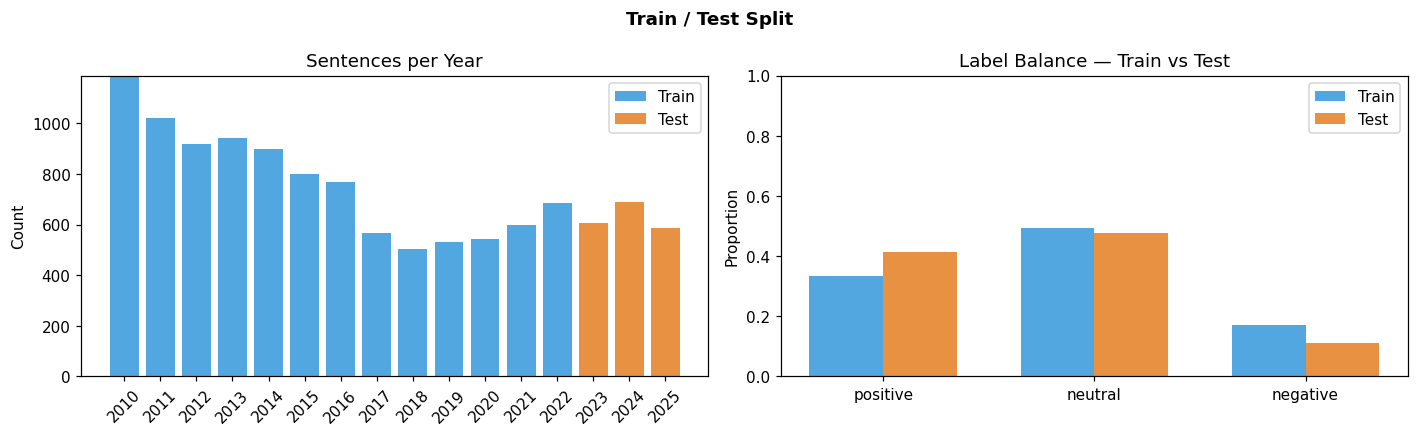

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Train / Test Split', fontsize=12, fontweight='bold')

all_years  = sorted(long['year_int'].unique())
tr_yc = train_all['year_int'].value_counts()
te_yc = test_all['year_int'].value_counts()
tr_v  = [tr_yc.get(y, 0) for y in all_years]
te_v  = [te_yc.get(y, 0) for y in all_years]
x     = range(len(all_years))

axes[0].bar(x, tr_v, label='Train', color='#3498db', alpha=0.85)
axes[0].bar(x, te_v, bottom=tr_v, label='Test', color='#e67e22', alpha=0.85)
axes[0].set_xticks(list(x)); axes[0].set_xticklabels(all_years, rotation=45)
axes[0].set_title('Sentences per Year'); axes[0].set_ylabel('Count'); axes[0].legend()

LABELS_ORDER = ['positive', 'neutral', 'negative']
tr_p = [train_all['sentiment_label'].value_counts(normalize=True).get(l, 0) for l in LABELS_ORDER]
te_p = [test_all['sentiment_label'].value_counts(normalize=True).get(l, 0)  for l in LABELS_ORDER]
bx = np.arange(3); w = 0.35
axes[1].bar(bx - w/2, tr_p, w, label='Train', color='#3498db', alpha=0.85)
axes[1].bar(bx + w/2, te_p, w, label='Test',  color='#e67e22', alpha=0.85)
axes[1].set_xticks(bx); axes[1].set_xticklabels(LABELS_ORDER)
axes[1].set_title('Label Balance — Train vs Test')
axes[1].set_ylabel('Proportion'); axes[1].set_ylim(0, 1.0); axes[1].legend()

plt.tight_layout(); plt.show()


## 5. Stratified Sample for CPU-Friendly Training

The full dataset (~12 000 sentences) would require 30+ minutes per epoch on CPU.
We draw a **stratified sample** (1 500 train + 300 test) preserving label proportions.

> **To use the full data**: delete this cell and replace `train_df` / `test_df` with
> `train_all` / `test_all` below, then set `EPOCHS = 3` and run on a GPU.

In [8]:
TRAIN_SAMPLE = 1500
TEST_SAMPLE  = 300

def stratified_sample(df, n, label_col='sentiment_label', seed=SEED):
    """Draw n rows with label proportions preserved."""
    from sklearn.model_selection import train_test_split
    _, sampled = train_test_split(
        df, test_size=min(n, len(df)),
        stratify=df[label_col], random_state=seed)
    return sampled.reset_index(drop=True)

train_df = stratified_sample(train_all, TRAIN_SAMPLE)
test_df  = stratified_sample(test_all,  TEST_SAMPLE)

print(f'train_df : {len(train_df):,} rows')
print(train_df['sentiment_label'].value_counts())
print()
print(f'test_df  : {len(test_df):,} rows')
print(test_df['sentiment_label'].value_counts())


train_df : 1,500 rows
sentiment_label
neutral     741
positive    501
negative    258
Name: count, dtype: int64

test_df  : 300 rows
sentiment_label
neutral     143
positive    124
negative     33
Name: count, dtype: int64


## 6. FinBERT Setup & Tokenisation

In [9]:
MODEL_NAME = 'ProsusAI/finbert'
LABEL2ID   = {'positive': 0, 'neutral': 1, 'negative': 2}
ID2LABEL   = {0: 'positive', 1: 'neutral', 2: 'negative'}
MAX_LEN    = 128
BATCH_SIZE = 16
EPOCHS     = 3
LR         = 2e-5

print(f'Loading tokeniser: {MODEL_NAME} ...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def encode(examples):
    return tokenizer(examples['processed_text'],
                     truncation=True, padding='max_length', max_length=MAX_LEN)

def to_hf_dataset(split_df):
    tmp = split_df[['processed_text', 'sentiment_label']].copy()
    tmp['label'] = tmp['sentiment_label'].map(LABEL2ID)
    ds = HFDataset.from_pandas(tmp[['processed_text', 'label']])
    return ds.map(encode, batched=True, remove_columns=['processed_text'])

print('Tokenising...')
train_ds = to_hf_dataset(train_df)
test_ds  = to_hf_dataset(test_df)
print(f'train_ds : {train_ds}')
print(f'test_ds  : {test_ds}')


Loading tokeniser: ProsusAI/finbert ...


Tokenising...


Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

train_ds : Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1500
})
test_ds  : Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 300
})


## 7. Fine-Tune FinBERT

In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'f1_weighted' : f1_score(labels, preds, average='weighted', zero_division=0),
        'f1_macro'    : f1_score(labels, preds, average='macro',    zero_division=0),
        'precision_wt': precision_score(labels, preds, average='weighted', zero_division=0),
        'recall_wt'   : recall_score(   labels, preds, average='weighted', zero_division=0),
    }

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID,
    ignore_mismatched_sizes=True)

training_args = TrainingArguments(
    output_dir                  = './finbert_ckpt',
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate               = LR,
    weight_decay                = 0.01,
    warmup_ratio                = 0.1,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1_weighted',
    greater_is_better           = True,
    logging_steps               = 20,
    seed                        = SEED,
    report_to                   = 'none',
    fp16                        = torch.cuda.is_available(),
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_ds,
    eval_dataset    = test_ds,
    compute_metrics = compute_metrics,
    data_collator   = DataCollatorWithPadding(tokenizer),
)

print('Fine-tuning FinBERT...')
train_result = trainer.train()
print(f'\nTraining loss : {train_result.training_loss:.4f}')


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Fine-tuning FinBERT...


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.encoder.layer.0.output.LayerNorm.beta', 'bert.encoder.layer.0.output.LayerNorm.gamma', 'bert.encoder.layer.1.attention.output.LayerNorm.beta', 'bert.encoder.layer.1.attention.output.LayerNorm.gamma', 'bert.encoder.layer.1.output.LayerNorm.beta', 'bert.encoder.layer.1.output.LayerNorm.gamma', 'bert.encoder.layer.2.attention.output.LayerNorm.beta', 'bert.encoder.layer.2.attention.output.LayerNorm.gamma', 'bert.encoder.layer.2.output.LayerNorm.beta', 'bert.encoder.layer.2.output.LayerNorm.gamma', 'bert.encoder.layer.3.attention.output.LayerNorm.beta', 'bert.encoder.layer.3.attention.output.LayerNorm.gamma', 'bert.encoder.layer.3.output.LayerNorm.beta', 'bert.encoder.layer.3.output.LayerNorm.gamma', 'bert.encoder.layer.4.attention.output.LayerNor


Training loss : 0.6436


## 8. Evaluation — Full Metrics

In [11]:
LABELS_ORDER = ['positive', 'neutral', 'negative']

pred_out   = trainer.predict(test_ds)
y_pred_ids = np.argmax(pred_out.predictions, axis=-1)
y_true_ids = pred_out.label_ids
y_pred     = [ID2LABEL[i] for i in y_pred_ids]
y_true     = [ID2LABEL[i] for i in y_true_ids]

fb_prec_mac = precision_score(y_true, y_pred, average='macro',    labels=LABELS_ORDER, zero_division=0)
fb_rec_mac  = recall_score(   y_true, y_pred, average='macro',    labels=LABELS_ORDER, zero_division=0)
fb_f1_mac   = f1_score(       y_true, y_pred, average='macro',    labels=LABELS_ORDER, zero_division=0)
fb_prec_wt  = precision_score(y_true, y_pred, average='weighted', labels=LABELS_ORDER, zero_division=0)
fb_rec_wt   = recall_score(   y_true, y_pred, average='weighted', labels=LABELS_ORDER, zero_division=0)
fb_f1_wt    = f1_score(       y_true, y_pred, average='weighted', labels=LABELS_ORDER, zero_division=0)

print('=' * 55)
print('FinBERT Fine-Tuned  —  Evaluation Results')
print('=' * 55)
print(f'  Macro  Precision : {fb_prec_mac:.4f}')
print(f'  Macro  Recall    : {fb_rec_mac:.4f}')
print(f'  Macro  F1        : {fb_f1_mac:.4f}')
print(f'  Wtd.   Precision : {fb_prec_wt:.4f}')
print(f'  Wtd.   Recall    : {fb_rec_wt:.4f}')
print(f'  Wtd.   F1        : {fb_f1_wt:.4f}')
print()
print(classification_report(y_true, y_pred, labels=LABELS_ORDER, digits=4))


FinBERT Fine-Tuned  —  Evaluation Results
  Macro  Precision : 0.7108
  Macro  Recall    : 0.6989
  Macro  F1        : 0.7027
  Wtd.   Precision : 0.7818
  Wtd.   Recall    : 0.7867
  Wtd.   F1        : 0.7825

              precision    recall  f1-score   support

    positive     0.8116    0.9032    0.8550       124
     neutral     0.8209    0.7692    0.7942       143
    negative     0.5000    0.4242    0.4590        33

    accuracy                         0.7867       300
   macro avg     0.7108    0.6989    0.7027       300
weighted avg     0.7818    0.7867    0.7825       300



## 9. Confusion Matrix

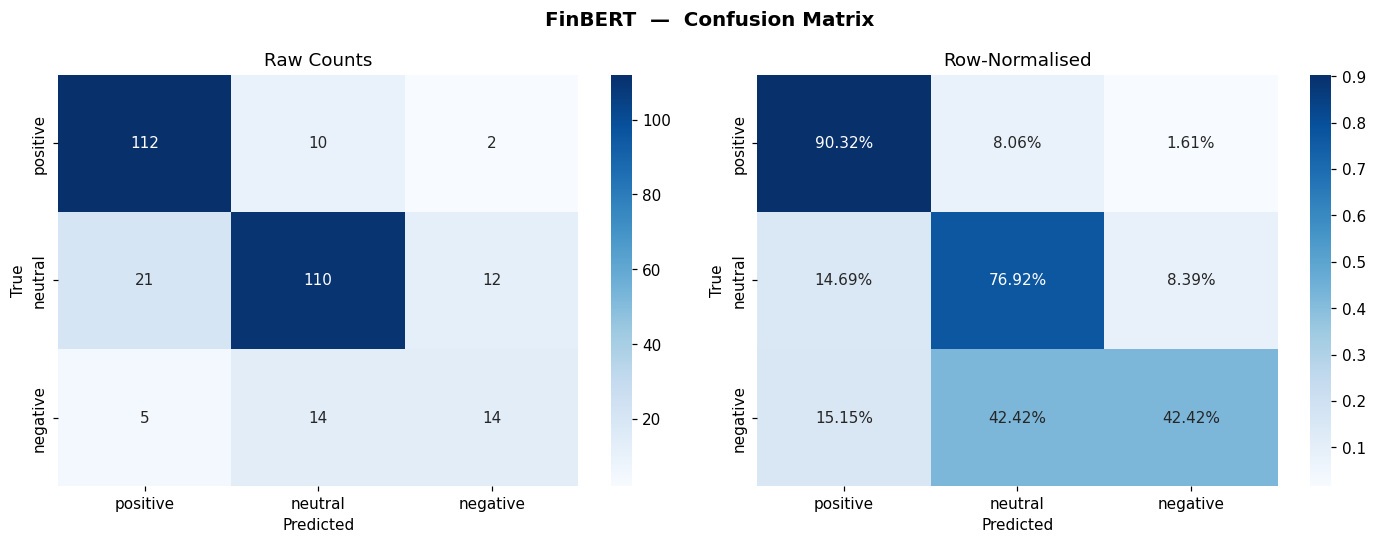

In [12]:
cm_fb = confusion_matrix(y_true, y_pred, labels=LABELS_ORDER)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('FinBERT  —  Confusion Matrix', fontsize=13, fontweight='bold')

sns.heatmap(cm_fb, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS_ORDER, yticklabels=LABELS_ORDER, ax=axes[0])
axes[0].set_title('Raw Counts')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

cm_fb_n = cm_fb.astype(float) / (cm_fb.sum(axis=1, keepdims=True) + 1e-9)
sns.heatmap(cm_fb_n, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=LABELS_ORDER, yticklabels=LABELS_ORDER, ax=axes[1])
axes[1].set_title('Row-Normalised')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout(); plt.show()


## 10. Baseline: Loughran-McDonald Dictionary + Linear SVM

Features: TF-IDF (unigrams + bigrams, top 5 000) concatenated with 6 LM
lexicon count features (positive count, negative count, difference, and
their normalised versions).

LM Dict + SVM Baseline  —  Evaluation Results
  Macro  Precision : 0.9722
  Macro  Recall    : 0.9930
  Macro  F1        : 0.9820
  Wtd.   Precision : 0.9908
  Wtd.   Recall    : 0.9900
  Wtd.   F1        : 0.9902

              precision    recall  f1-score   support

    positive     1.0000    1.0000    1.0000       124
     neutral     1.0000    0.9790    0.9894       143
    negative     0.9167    1.0000    0.9565        33

    accuracy                         0.9900       300
   macro avg     0.9722    0.9930    0.9820       300
weighted avg     0.9908    0.9900    0.9902       300



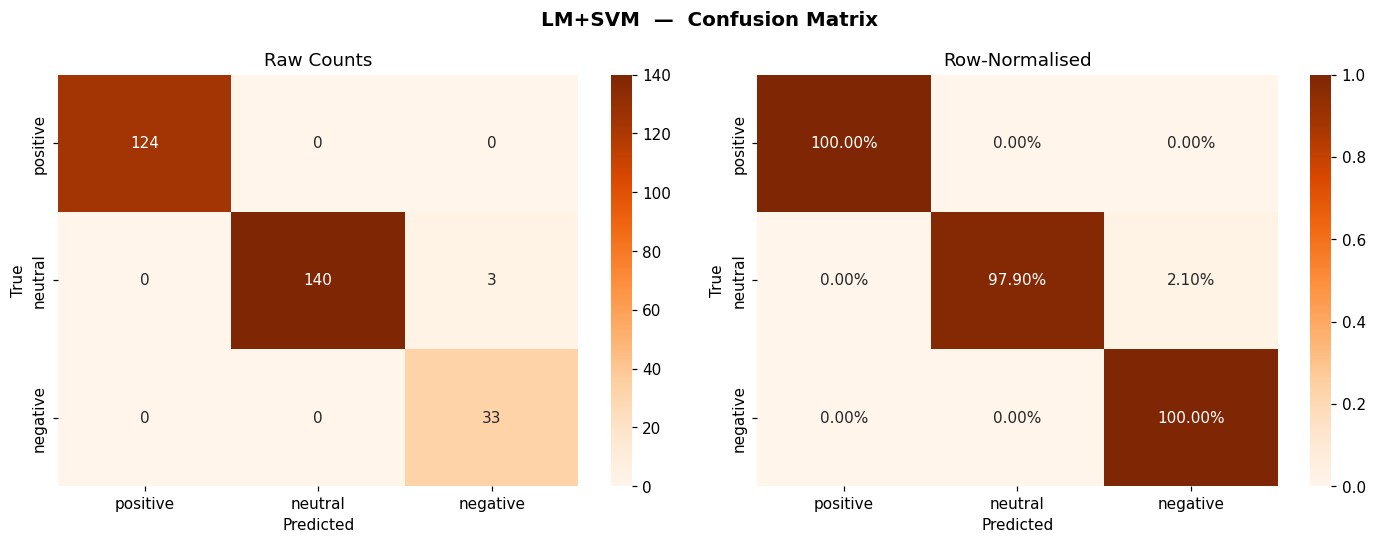

In [13]:
def lm_features(texts):
    rows = []
    for txt in texts:
        words = set(txt.lower().split())
        n     = max(len(txt.split()), 1)
        pos   = len(words & LM_POSITIVE)
        neg   = len(words & LM_NEGATIVE)
        rows.append([pos, neg, pos - neg, pos / n, neg / n, (pos - neg) / n])
    return np.array(rows, dtype=float)

X_tr_txt = train_df['processed_text'].tolist()
X_te_txt = test_df['processed_text'].tolist()
y_train  = train_df['sentiment_label'].tolist()
y_test   = test_df['sentiment_label'].tolist()

tfidf     = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=1)
X_tr_comb = hstack([tfidf.fit_transform(X_tr_txt), csr_matrix(lm_features(X_tr_txt))])
X_te_comb = hstack([tfidf.transform(X_te_txt),     csr_matrix(lm_features(X_te_txt))])

svm = LinearSVC(random_state=SEED, max_iter=5000, C=1.0)
svm.fit(X_tr_comb, y_train)
y_svm = svm.predict(X_te_comb)

svm_prec_mac = precision_score(y_test, y_svm, average='macro',    labels=LABELS_ORDER, zero_division=0)
svm_rec_mac  = recall_score(   y_test, y_svm, average='macro',    labels=LABELS_ORDER, zero_division=0)
svm_f1_mac   = f1_score(       y_test, y_svm, average='macro',    labels=LABELS_ORDER, zero_division=0)
svm_prec_wt  = precision_score(y_test, y_svm, average='weighted', labels=LABELS_ORDER, zero_division=0)
svm_rec_wt   = recall_score(   y_test, y_svm, average='weighted', labels=LABELS_ORDER, zero_division=0)
svm_f1_wt    = f1_score(       y_test, y_svm, average='weighted', labels=LABELS_ORDER, zero_division=0)

print('=' * 55)
print('LM Dict + SVM Baseline  —  Evaluation Results')
print('=' * 55)
print(f'  Macro  Precision : {svm_prec_mac:.4f}')
print(f'  Macro  Recall    : {svm_rec_mac:.4f}')
print(f'  Macro  F1        : {svm_f1_mac:.4f}')
print(f'  Wtd.   Precision : {svm_prec_wt:.4f}')
print(f'  Wtd.   Recall    : {svm_rec_wt:.4f}')
print(f'  Wtd.   F1        : {svm_f1_wt:.4f}')
print()
print(classification_report(y_test, y_svm, labels=LABELS_ORDER, digits=4))

cm_svm = confusion_matrix(y_test, y_svm, labels=LABELS_ORDER)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('LM+SVM  —  Confusion Matrix', fontsize=13, fontweight='bold')
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=LABELS_ORDER, yticklabels=LABELS_ORDER, ax=axes[0])
axes[0].set_title('Raw Counts'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
cm_svm_n = cm_svm.astype(float) / (cm_svm.sum(axis=1, keepdims=True) + 1e-9)
sns.heatmap(cm_svm_n, annot=True, fmt='.2%', cmap='Oranges',
            xticklabels=LABELS_ORDER, yticklabels=LABELS_ORDER, ax=axes[1])
axes[1].set_title('Row-Normalised'); axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
plt.tight_layout(); plt.show()


## 11. Model Comparison Summary

Model Comparison Summary
                      Precision (Macro)  Recall (Macro)  F1 (Macro)  Precision (Weighted)  Recall (Weighted)  F1 (Weighted)
Model                                                                                                                      
LM+SVM (Baseline)                0.9722          0.9930      0.9820                0.9908             0.9900         0.9902
FinBERT (Fine-tuned)             0.7108          0.6989      0.7027                0.7818             0.7867         0.7825


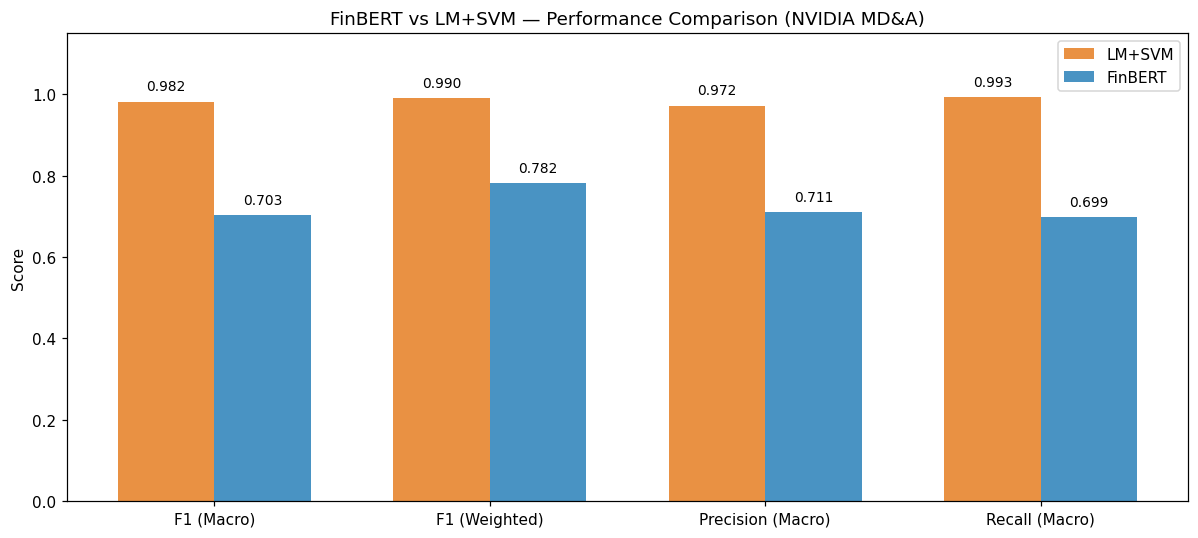

In [14]:
cmp = pd.DataFrame({
    'Model'               : ['LM+SVM (Baseline)', 'FinBERT (Fine-tuned)'],
    'Precision (Macro)'   : [svm_prec_mac, fb_prec_mac],
    'Recall (Macro)'      : [svm_rec_mac,  fb_rec_mac],
    'F1 (Macro)'          : [svm_f1_mac,   fb_f1_mac],
    'Precision (Weighted)': [svm_prec_wt,  fb_prec_wt],
    'Recall (Weighted)'   : [svm_rec_wt,   fb_rec_wt],
    'F1 (Weighted)'       : [svm_f1_wt,    fb_f1_wt],
}).set_index('Model')

print('Model Comparison Summary')
print('=' * 70)
print(cmp.to_string(float_format='{:.4f}'.format))

metrics_show = ['F1 (Macro)', 'F1 (Weighted)', 'Precision (Macro)', 'Recall (Macro)']
bx = np.arange(len(metrics_show)); w = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(bx - w/2, [cmp.loc['LM+SVM (Baseline)',    m] for m in metrics_show],
            w, label='LM+SVM',  color='#e67e22', alpha=0.85)
b2 = ax.bar(bx + w/2, [cmp.loc['FinBERT (Fine-tuned)', m] for m in metrics_show],
            w, label='FinBERT', color='#2980b9', alpha=0.85)
ax.set_xticks(bx); ax.set_xticklabels(metrics_show)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.15)
ax.set_title('FinBERT vs LM+SVM — Performance Comparison (NVIDIA MD&A)')
ax.legend()
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()
